In [1]:
import sys

import torch

import pandas as pd

import pm4py
from pm4py.visualization.petri_net import visualizer as pn_vis

from config.feature_config import FeatureConfig
from config.ga_config import GAConfig

from utils.general_utils import set_stdout_to_file, set_seed
from utils.feature_utils import df_to_sequence_array

from model.preprocessor import PreprocessorArtifacts

from model.next_event_model import ProcessLSTM
from model.model_wrapper import ModelWrapper

from ga_search.search import CounterfactualGA

from process.engine import ProcessModelConstraintEngine
from process.experimenter import ExperimentHandler

### --- Load Dataset & Models ---

In [2]:
set_seed(seed=42)

In [3]:
df = pd.read_excel(
    "../../data/bpic20_Dom.xlsx",
    engine="openpyxl",
    keep_default_na=False,
    dtype={
        "case:concept:name": "string",
        "concept:name": "string",
        "org:resource": "string",
        "org:role": "string",
        "case:Amount": "float32",
        "time_delta": "float32",
    }
)

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

In [4]:
df.head(20)

,case:concept:name,time:timestamp,case:Amount,concept:name,org:resource,org:role,time_delta
0,declaration 100000,2018-01-30 09:20:07,600.844116,Declaration SUBMITTED by EMPLOYEE,STAFF MEMBER,EMPLOYEE,0.0
1,declaration 100000,2018-02-07 09:58:46,600.844116,Declaration APPROVED by ADMINISTRATION,STAFF MEMBER,ADMINISTRATION,693519.0
2,declaration 100000,2018-02-08 10:59:05,600.844116,Declaration FINAL_APPROVED by SUPERVISOR,STAFF MEMBER,SUPERVISOR,90019.0
3,declaration 100000,2018-02-09 12:42:49,600.844116,Request Payment,SYSTEM,UNDEFINED,92624.0
4,declaration 100000,2018-02-12 17:31:20,600.844116,Payment Handled,SYSTEM,UNDEFINED,276511.0
5,declaration 100005,2018-01-30 09:38:54,35.133686,Declaration SUBMITTED by EMPLOYEE,STAFF MEMBER,EMPLOYEE,0.0
6,declaration 100005,2018-01-30 09:38:57,35.133686,Declaration APPROVED by ADMINISTRATION,STAFF MEMBER,ADMINISTRATION,3.0
7,declaration 100005,2018-01-30 10:04:10,35.133686,Declaration FINAL_APPROVED by SUPERVISOR,STAFF MEMBER,SUPERVISOR,1513.0
8,declaration 100005,2018-01-31 12:45:18,35.133686,Request Payment,SYSTEM,UNDEFINED,96068.0
9,declaration 100005,2018-02-01 17:31:17,35.133686,Payment Handled,SYSTEM,UNDEFINED,103559.0


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
feature_config = FeatureConfig.load()

In [7]:
feature_config.summary()

  activity_feature:    concept:name
  feature_order:       ['case:Amount', 'concept:name', 'org:resource', 'org:role', 'time_delta']
--------------------------------------------------------------------------------------------------------------------------------------
Feature                        Type           Level    Vary   Range/Categories                         MAD        Source              
--------------------------------------------------------------------------------------------------------------------------------------
time_delta                     continuous     event    yes    [2.00, 284911.00]                        42289.5000 quantile_derived    
case:Amount                    continuous     case     yes    [6.91, 219.03]                           25.3885    quantile_derived    
org:resource                   categorical    event    yes    ['STAFF MEMBER', 'SYSTEM']               N/A        data_derived        
org:role                       categorical    event    ye

In [8]:
preprocessor_artifacts = PreprocessorArtifacts.load()

In [9]:
model = ProcessLSTM.load()

In [10]:
model_wrapper = ModelWrapper(
    model=model,
    preprocessor_artifacts=preprocessor_artifacts,
    device=device
)

### --- Process Constraints ---

In [11]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(
    df,
    noise_threshold=0.5,
    case_id_key='case:concept:name',  
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

engine = ProcessModelConstraintEngine(
    petri_net=net,
    initial_marking=initial_marking,
    final_marking=final_marking
)
engine.save()

In [12]:
# engine = ProcessModelConstraintEngine.load()

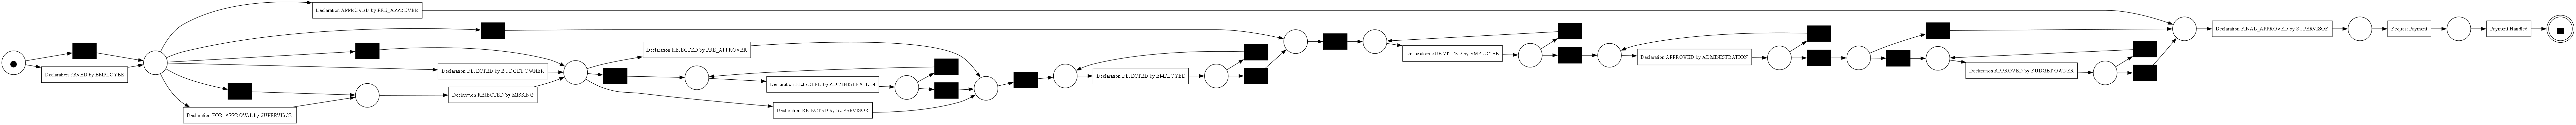

In [13]:
gviz = pn_vis.apply(
    net,
    initial_marking,
    final_marking,
)

pn_vis.view(gviz)

In [14]:
engine.parallel_sets

[]

In [15]:
engine.branching_sets

[{'Declaration APPROVED by ADMINISTRATION',
  'Declaration APPROVED by BUDGET OWNER',
  'Declaration APPROVED by PRE_APPROVER',
  'Declaration FOR_APPROVAL by SUPERVISOR',
  'Declaration REJECTED by ADMINISTRATION',
  'Declaration REJECTED by BUDGET OWNER',
  'Declaration REJECTED by EMPLOYEE',
  'Declaration REJECTED by MISSING',
  'Declaration REJECTED by PRE_APPROVER',
  'Declaration REJECTED by SUPERVISOR',
  'Declaration SUBMITTED by EMPLOYEE'},
 {'Declaration FOR_APPROVAL by SUPERVISOR',
  'Declaration REJECTED by ADMINISTRATION',
  'Declaration REJECTED by BUDGET OWNER',
  'Declaration REJECTED by EMPLOYEE',
  'Declaration REJECTED by MISSING',
  'Declaration REJECTED by PRE_APPROVER',
  'Declaration REJECTED by SUPERVISOR'},
 {'Declaration FOR_APPROVAL by SUPERVISOR',
  'Declaration REJECTED by BUDGET OWNER',
  'Declaration REJECTED by MISSING'},
 {'Declaration REJECTED by ADMINISTRATION',
  'Declaration REJECTED by PRE_APPROVER',
  'Declaration REJECTED by SUPERVISOR'}]

### --- Experiments Generation ---

In [16]:
log_file, original_stdout = set_stdout_to_file(filepath="logs/bpic20_Dom-cf_generated_experiments_ga_output.txt", console=False)

In [17]:
generator = ExperimentHandler(
    constraint_engine=engine,
)

In [18]:
exp_df_sin = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_single_desired",
    min_desired=1,
    max_desired=1,
)

In [19]:
exp_df_mul = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_multiple_desired",
    min_desired=2,
)

In [20]:
max(exp_df_sin['num_desired'])

1

In [21]:
len(exp_df_sin)

220

In [22]:
exp_df_sin.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,declaration 142992,4,0,3,1,"(Declaration SUBMITTED by EMPLOYEE, Declaratio...","(Declaration SUBMITTED by EMPLOYEE, Declaratio...",{2: {'Declaration APPROVED by BUDGET OWNER'}},4622,2503,10,window_variant_mixed
1,0,declaration 113587,5,0,3,1,"(Declaration SUBMITTED by EMPLOYEE, Declaratio...","(Declaration SUBMITTED by EMPLOYEE, Declaratio...",{2: {'Declaration APPROVED by BUDGET OWNER'}},4622,2503,10,window_variant_mixed
2,0,declaration 115669,4,0,3,1,"(Declaration SUBMITTED by EMPLOYEE, Declaratio...","(Declaration SUBMITTED by EMPLOYEE, Declaratio...",{2: {'Declaration APPROVED by BUDGET OWNER'}},4622,2503,10,window_variant_mixed
3,0,declaration 108114,5,0,3,1,"(Declaration SUBMITTED by EMPLOYEE, Declaratio...","(Declaration SUBMITTED by EMPLOYEE, Declaratio...",{2: {'Declaration APPROVED by BUDGET OWNER'}},4622,2503,10,window_variant_mixed
4,0,declaration 138710,4,0,3,1,"(Declaration SUBMITTED by EMPLOYEE, Declaratio...","(Declaration SUBMITTED by EMPLOYEE, Declaratio...",{2: {'Declaration APPROVED by BUDGET OWNER'}},4622,2503,10,window_variant_mixed


In [23]:
min(exp_df_mul['num_desired'])

2

In [24]:
max(exp_df_mul['num_desired'])

9

In [25]:
len(exp_df_mul)

420

In [26]:
exp_df_mul.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,declaration 142992,4,0,3,2,"(Declaration SUBMITTED by EMPLOYEE, Declaratio...","(Declaration SUBMITTED by EMPLOYEE, Declaratio...",{1: {'Declaration FINAL_APPROVED by SUPERVISOR...,4622,1395,10,window_variant_mixed
1,0,declaration 113587,5,0,3,2,"(Declaration SUBMITTED by EMPLOYEE, Declaratio...","(Declaration SUBMITTED by EMPLOYEE, Declaratio...",{1: {'Declaration FINAL_APPROVED by SUPERVISOR...,4622,1395,10,window_variant_mixed
2,0,declaration 115669,4,0,3,2,"(Declaration SUBMITTED by EMPLOYEE, Declaratio...","(Declaration SUBMITTED by EMPLOYEE, Declaratio...",{1: {'Declaration FINAL_APPROVED by SUPERVISOR...,4622,1395,10,window_variant_mixed
3,0,declaration 108114,5,0,3,2,"(Declaration SUBMITTED by EMPLOYEE, Declaratio...","(Declaration SUBMITTED by EMPLOYEE, Declaratio...",{1: {'Declaration FINAL_APPROVED by SUPERVISOR...,4622,1395,10,window_variant_mixed
4,0,declaration 138710,4,0,3,2,"(Declaration SUBMITTED by EMPLOYEE, Declaratio...","(Declaration SUBMITTED by EMPLOYEE, Declaratio...",{1: {'Declaration FINAL_APPROVED by SUPERVISOR...,4622,1395,10,window_variant_mixed


In [27]:
# exp_df_sin, metadata_sin = ExperimentHandler.load("experiments/cf_generated_experiments_single_desired")
# print("Mined using parameters:", metadata_sin["parameters"])

# exp_df_mul, metadata_mul = ExperimentHandler.load("experiments/cf_generated_experiments_multiple_desired")
# print("Mined using parameters:", metadata_mul["parameters"])

### --- Counterfactuals ---

In [28]:
ga_config = GAConfig(
    w_distance=1.0,
    w_sparsity=1.0,
    w_margin=1.0,
    w_process_violation=1.0,
)
ga_config.validate()

cf_GA = CounterfactualGA(
    ga_config=ga_config,
    feature_config=feature_config,
    model_wrapper=model_wrapper
)

In [29]:
results_sin = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_single_desired",
    exp_df=exp_df_sin,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/220 [00:00<?, ?case/s]

In [30]:
results_sin

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,declaration 142992,4,1,0,0.343039,0.248577,0.437500,0.407143,0.272727,...,0.911877,0.272727,0.000000e+00,0.0000,0.000000,0.00,0.639149,0.639149,0.999998,0.999998
1,0,declaration 115669,4,1,0,0.313831,0.252662,0.375000,0.400000,0.272727,...,0.947288,0.272727,0.000000e+00,0.0000,0.000000,0.00,0.674561,0.674561,0.999999,0.999999
2,0,declaration 138710,4,1,0,0.374265,0.323530,0.425000,0.428571,0.272727,...,0.898285,0.272727,0.000000e+00,0.0000,0.000000,0.00,0.625557,0.625557,0.999998,0.999998
3,0,declaration 141310,4,1,0,0.310757,0.271513,0.350000,0.435714,0.272727,...,0.947223,0.272727,0.000000e+00,0.0000,0.000000,0.00,0.674496,0.674496,0.999999,0.999999
4,0,declaration 113587,5,1,0,0.331662,0.288324,0.375000,0.378571,0.230769,...,0.803474,0.230769,0.000000e+00,0.0000,0.000000,0.00,0.572704,0.572704,0.999996,0.999996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,20,declaration 124561,11,1,0,0.389979,0.408084,0.371875,0.570000,0.400000,...,0.767474,0.400000,4.747443e-02,0.0000,0.094949,0.32,0.000000,0.539115,0.000000,0.999991
148,20,declaration 134394,11,1,0,0.445977,0.466954,0.425000,0.572000,0.400000,...,0.599991,0.400000,3.999149e-02,0.0625,0.017483,0.16,0.000000,0.196807,0.000000,0.000000
149,20,declaration 129484,11,1,0,0.338815,0.252630,0.425000,0.502000,0.400000,...,0.551252,0.400000,3.125156e-02,0.0625,0.000003,0.12,0.000000,0.374283,0.000000,0.000000
150,20,declaration 126499,11,1,0,0.418744,0.446863,0.390625,0.512000,0.388000,...,0.335061,0.160000,5.506113e-02,0.0625,0.047622,0.12,0.000000,0.000000,0.000000,0.000000


In [31]:
results_mul = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_multiple_desired",
    exp_df=exp_df_mul,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/420 [00:00<?, ?case/s]

In [32]:
results_mul

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,declaration 142992,4,2,0,0.523635,0.447270,0.600000,0.6000,0.235714,...,0.843673,0.000000,0.343673,0.5000,0.187346,0.50,0.000000,0.477192,0.0,0.500000
1,0,declaration 115669,4,2,0,0.590839,0.456679,0.725000,0.7375,0.128571,...,0.897965,0.000000,0.397965,0.5000,0.295931,0.50,0.000000,0.478329,0.0,0.500000
2,0,declaration 138710,4,2,0,0.615618,0.656236,0.575000,0.6750,0.064286,...,0.885571,0.000000,0.385571,0.5000,0.271142,0.50,0.000000,0.477258,0.0,0.500000
3,0,declaration 141310,4,2,0,0.423772,0.397544,0.450000,0.5750,0.414286,...,0.896416,0.000000,0.396416,0.5000,0.292833,0.50,0.000000,0.478378,0.0,0.500000
4,1,declaration 92054,4,2,0,0.217748,0.310495,0.125000,0.2875,0.142857,...,0.142857,0.142857,0.000000,0.0000,0.000000,0.00,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,40,declaration 124561,11,3,0,0.384443,0.343885,0.425000,0.4920,0.193548,...,0.233602,0.193548,0.000053,0.0000,0.000106,0.04,0.000000,0.827040,0.0,0.999998
263,40,declaration 134394,11,3,0,0.426720,0.450315,0.403125,0.5940,0.193548,...,0.629441,0.193548,0.115892,0.0000,0.231784,0.32,0.000000,0.782664,0.0,0.666667
264,40,declaration 129484,11,3,0,0.419059,0.409993,0.428125,0.5200,0.193548,...,0.408410,0.193548,0.094861,0.0625,0.127223,0.12,0.000000,0.812810,0.0,0.999983
265,40,declaration 126499,11,3,0,0.408204,0.388282,0.428125,0.5040,0.183871,...,0.089076,0.000000,0.013252,0.0000,0.026504,0.04,0.035824,0.680398,0.0,0.666667


### --- Cleanup ---

In [33]:
sys.stdout = original_stdout
log_file.close()